In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
from datetime import datetime

1. Data collection

In [2]:
now = datetime.now()

start = datetime(now.year-10, now.month, now.day)
end=now
ticker='AAPL'
df = yf.download(ticker, start, end)
df

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2016-07-05,21.624434,21.717771,21.503780,21.715494,110820800
2016-07-06,21.747372,21.776967,21.483299,21.535657,123796400
2016-07-07,21.840710,21.968193,21.767862,21.786073,100558400
2016-07-08,22.009171,22.056977,21.865752,21.965917,115648400
2016-07-11,22.077461,22.229986,22.020549,22.025101,95179600
...,...,...,...,...,...
2026-06-26,283.779999,285.950012,274.209991,275.000000,261775500
2026-06-29,281.739990,288.369995,279.850006,286.730011,66427000


In [3]:
df.isna().sum()

Price   Ticker
Close   AAPL      0
High    AAPL      0
Low     AAPL      0
Open    AAPL      0
Volume  AAPL      0
dtype: int64

In [4]:
df.describe()

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
count,2513.000000,2513.000000,2513.000000,2513.000000,2.513000e+03
mean,126.598498,127.873020,125.213214,126.484322,9.573479e+07
std,77.898627,78.678793,77.073978,77.834309,5.465112e+07
min,21.624434,21.717771,21.483299,21.535657,1.791060e+07
25%,45.582218,45.989823,45.228800,45.622268,5.657590e+07
50%,131.162643,132.539402,129.802348,131.396525,8.396200e+07
75%,182.539017,184.360771,180.684735,182.286616,1.156272e+08
max,315.200012,317.399994,309.649994,314.179993,4.479400e+08


In [5]:
df.reset_index()

Price,Date,Close,High,Low,Open,Volume
Ticker,,AAPL,AAPL,AAPL,AAPL,AAPL
0,2016-07-05,21.624434,21.717771,21.503780,21.715494,110820800
1,2016-07-06,21.747372,21.776967,21.483299,21.535657,123796400
2,2016-07-07,21.840710,21.968193,21.767862,21.786073,100558400
3,2016-07-08,22.009171,22.056977,21.865752,21.965917,115648400
4,2016-07-11,22.077461,22.229986,22.020549,22.025101,95179600
...,...,...,...,...,...,...
2508,2026-06-26,283.779999,285.950012,274.209991,275.000000,261775500
2509,2026-06-29,281.739990,288.369995,279.850006,286.730011,66427000
2510,2026-06-30,289.359985,289.940002,280.700012,281.170013,65100200


In [6]:
df.head()

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2016-07-05,21.624434,21.717771,21.503780,21.715494,110820800
2016-07-06,21.747372,21.776967,21.483299,21.535657,123796400
2016-07-07,21.840710,21.968193,21.767862,21.786073,100558400
2016-07-08,22.009171,22.056977,21.865752,21.965917,115648400
2016-07-11,22.077461,22.229986,22.020549,22.025101,95179600


In [7]:
df = df.reset_index()

In [8]:
df.head()

Price,Date,Close,High,Low,Open,Volume
Ticker,,AAPL,AAPL,AAPL,AAPL,AAPL
0,2016-07-05,21.624434,21.717771,21.503780,21.715494,110820800
1,2016-07-06,21.747372,21.776967,21.483299,21.535657,123796400
2,2016-07-07,21.840710,21.968193,21.767862,21.786073,100558400
3,2016-07-08,22.009171,22.056977,21.865752,21.965917,115648400
4,2016-07-11,22.077461,22.229986,22.020549,22.025101,95179600


Text(0, 0.5, 'Close price')

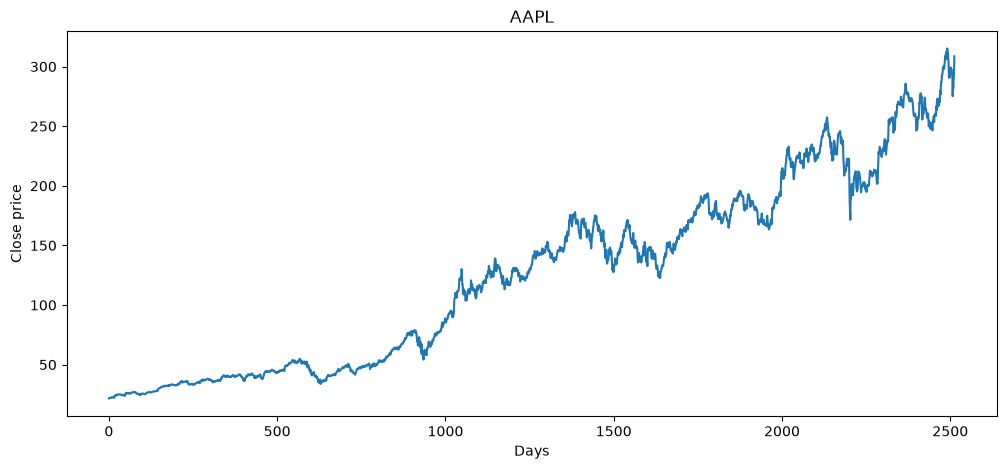

In [9]:
plt.figure(figsize=(12,5))
plt.plot(df.Close)
plt.title(ticker)
plt.xlabel('Days')
plt.ylabel('Close price')

2 Feature Engineering

100 days moving avarage

In [10]:
df['MA_100']=df.Close.rolling(100).mean()
df.head()

Price,Date,Close,High,Low,Open,Volume,MA_100
Ticker,,AAPL,AAPL,AAPL,AAPL,AAPL,
0,2016-07-05,21.624434,21.717771,21.503780,21.715494,110820800,NaN
1,2016-07-06,21.747372,21.776967,21.483299,21.535657,123796400,NaN
2,2016-07-07,21.840710,21.968193,21.767862,21.786073,100558400,NaN
3,2016-07-08,22.009171,22.056977,21.865752,21.965917,115648400,NaN
4,2016-07-11,22.077461,22.229986,22.020549,22.025101,95179600,NaN


In [11]:
df.tail()

Price,Date,Close,High,Low,Open,Volume,MA_100
Ticker,,AAPL,AAPL,AAPL,AAPL,AAPL,
2508,2026-06-26,283.779999,285.950012,274.209991,275.000000,261775500,275.981114
2509,2026-06-29,281.739990,288.369995,279.850006,286.730011,66427000,276.108711
2510,2026-06-30,289.359985,289.940002,280.700012,281.170013,65100200,276.242539
2511,2026-07-01,294.380005,296.589996,289.200012,293.440002,50164200,276.432355
2512,2026-07-02,308.630005,309.420013,293.679993,294.119995,75352800,276.742613


Text(0, 0.5, 'Price')

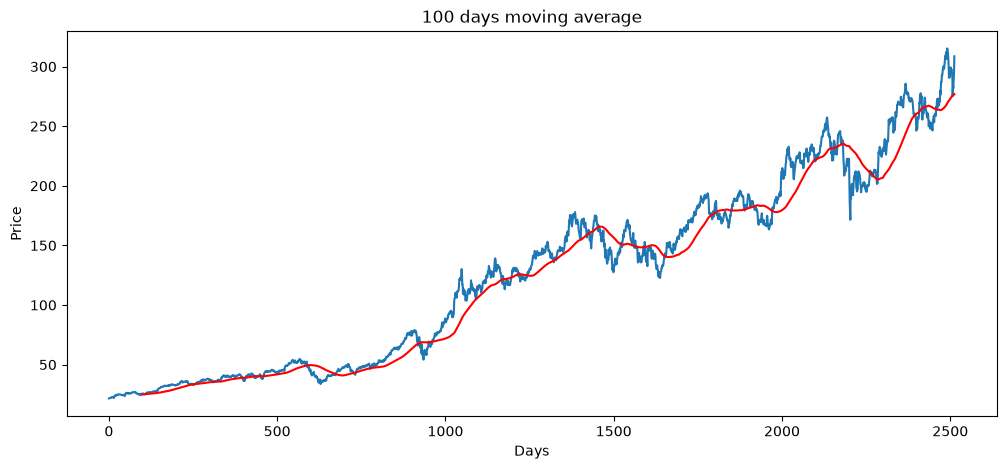

In [12]:
plt.figure(figsize=(12,5))
plt.plot(df.Close)
plt.plot(df['MA_100'], 'r')
plt.title('100 days moving average')
plt.xlabel('Days')
plt.ylabel('Price')


200 days moving avarage

In [13]:
df['MA_200']=df.Close.rolling(200).mean()
df.head(203)

Price,Date,Close,High,Low,Open,Volume,MA_100,MA_200
Ticker,,AAPL,AAPL,AAPL,AAPL,AAPL,,
0,2016-07-05,21.624434,21.717771,21.503780,21.715494,110820800,NaN,NaN
1,2016-07-06,21.747372,21.776967,21.483299,21.535657,123796400,NaN,NaN
2,2016-07-07,21.840710,21.968193,21.767862,21.786073,100558400,NaN,NaN
3,2016-07-08,22.009171,22.056977,21.865752,21.965917,115648400,NaN,NaN
4,2016-07-11,22.077461,22.229986,22.020549,22.025101,95179600,NaN,NaN
...,...,...,...,...,...,...,...,...
198,2017-04-18,32.625031,32.819116,32.604236,32.673554,58790000,29.526179,NaN
199,2017-04-19,32.504879,32.809874,32.451737,32.782148,69313600,29.594023,27.227783
200,2017-04-20,32.911541,33.022447,32.615790,32.629653,93278400,29.667245,27.284219


Text(0, 0.5, 'Close price')

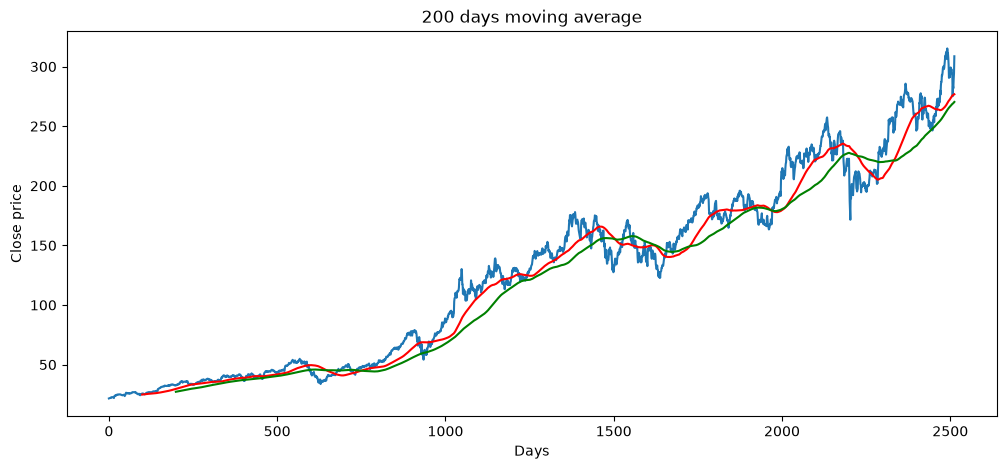

In [14]:
plt.figure(figsize=(12,5))
plt.plot(df.Close)
plt.plot(df['MA_100'], 'red')
plt.plot(df['MA_200'], 'g')
plt.title('200 days moving average')
plt.xlabel('Days')
plt.ylabel('Close price')

In [15]:
df['Percentage Changed']=df.Close.pct_change()

In [16]:
df[['Close', 'Percentage Changed']]

Price,Close,Percentage Changed
Ticker,AAPL,
0,21.624434,NaN
1,21.747372,0.005685
2,21.840710,0.004292
3,22.009171,0.007713
4,22.077461,0.003103
...,...,...
2508,283.779999,0.031365
2509,281.739990,-0.007189
2510,289.359985,0.027046


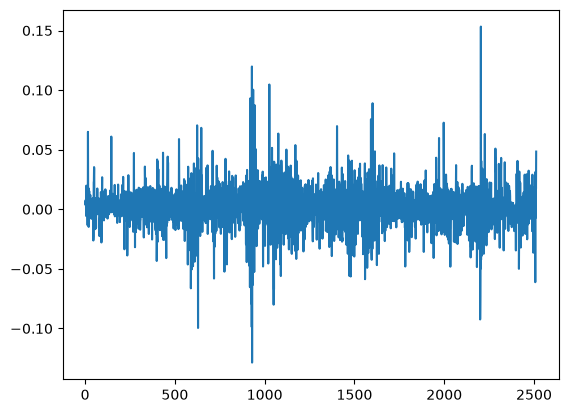

In [17]:
plt.plot(df['Percentage Changed'])

3 Data Preprocessing

In [18]:
df.shape

(2513, 9)

In [19]:
data_training=pd.DataFrame(df.Close[0:int(len(df)*0.7)])
data_testing=pd.DataFrame(df.Close[int(len(df)*0.7):int(len(df))])
print(data_training)
print(data_testing)

Ticker        AAPL
0        21.624434
1        21.747372
2        21.840710
3        22.009171
4        22.077461
...            ...
1754    184.099091
1755    182.708572
1756    185.460007
1757    186.633514
1758    186.968811

[1759 rows x 1 columns]
Ticker        AAPL
1759    191.288269
1760    189.799164
1761    188.684784
1762    189.158142
1763    188.043777
...            ...
2508    283.779999
2509    281.739990
2510    289.359985
2511    294.380005
2512    308.630005

[754 rows x 1 columns]


In [20]:
from sklearn.preprocessing import MinMaxScaler
scaler=MinMaxScaler(feature_range=(0, 1))

In [21]:
data_training_array=scaler.fit_transform(data_training)
data_training_array

array([[0.00000000e+00],
       [7.43527890e-04],
       [1.30803461e-03],
       ...,
       [9.90874777e-01],
       [9.97972132e-01],
       [1.00000000e+00]], shape=(1759, 1))

In [22]:
x_train=[]
y_train=[]
for i in range(100, data_training_array.shape[0]):
    x_train.append(data_training_array[i-100:i])
    y_train.append(data_training_array[i, 0])
x_train, y_train = np.array(x_train), np.array(y_train)


In [23]:
import tensorflow as tf

In [24]:
from keras.models import Sequential
from keras.layers import Dense, LSTM, Input

In [25]:
model = Sequential()
model.add(Input(shape=(100, 1)))
model.add(LSTM(units=128, activation='tanh', return_sequences=True))
model.add(LSTM(units=64))
model.add(Dense(25))
model.add(Dense(1))

In [26]:
model.compile(optimizer='adam', loss='mean_squared_error')
model.fit(x_train, y_train, epochs=50)

Epoch 1/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 16s 184ms/step - loss: 0.0083
Epoch 2/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 10s 183ms/step - loss: 6.4824e-04
Epoch 3/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 10s 175ms/step - loss: 6.2106e-04
Epoch 4/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 11s 183ms/step - loss: 5.9219e-04
Epoch 5/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 10s 179ms/step - loss: 5.8815e-04
Epoch 6/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 11s 184ms/step - loss: 5.3888e-04
Epoch 7/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 11s 189ms/step - loss: 5.9125e-04
Epoch 8/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 10s 183ms/step - loss: 7.0693e-04
Epoch 9/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 10s 186ms/step - loss: 5.6506e-04
Epoch 10/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 10s 187ms/step - loss: 5.0829e-04
Epoch 11/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 10s 186ms/step - loss: 4.9666e-04
Epoch 12/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 10s 184ms/step - loss: 4.9841e-04
Epoch 13/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 11s 192ms/step - loss: 4.8783e-04
Epoch 14/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 10s 178ms/step - loss: 4.

In [27]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                          │ (None, 100, 128)            │          66,560 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_1 (LSTM)                        │ (None, 64)                  │          49,408 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 25)                  │           1,625 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │              26 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 352,859 (1.35 MB)

 Trainable params: 117,619 (459.45 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 235,240 (918.91 KB)

In [28]:
model.save('stock_prediction_model.keras')

In [29]:
past_100_days = data_training.tail(100)

In [30]:
past_100_days


Ticker,AAPL
1659,149.197815
1660,152.069061
1661,149.384628
1662,148.352158
1663,148.716507
...,...
1754,184.099091
1755,182.708572
1756,185.460007
1757,186.633514


In [31]:
final_df = pd.concat([past_100_days, data_testing], ignore_index=True)
final_df

Ticker,AAPL
0,149.197815
1,152.069061
2,149.384628
3,148.352158
4,148.716507
...,...
849,283.779999
850,281.739990
851,289.359985
852,294.380005


In [32]:
input_data = scaler.fit_transform(final_df)
input_data

array([[0.03541459],
       [0.05209848],
       [0.0365001 ],
       [0.03050074],
       [0.03261786],
       [0.04886969],
       [0.04514997],
       [0.05733896],
       [0.04806852],
       [0.04143052],
       [0.01814037],
       [0.02060088],
       [0.02340479],
       [0.00801141],
       [0.0149357 ],
       [0.01201733],
       [0.        ],
       [0.0034336 ],
       [0.0327325 ],
       [0.04875514],
       [0.03599418],
       [0.04326179],
       [0.03021454],
       [0.01825466],
       [0.02952792],
       [0.04165954],
       [0.04394849],
       [0.06031461],
       [0.0554505 ],
       [0.0691841 ],
       [0.07994223],
       [0.07164506],
       [0.0779394 ],
       [0.08549321],
       [0.07422012],
       [0.07061487],
       [0.08846877],
       [0.09756755],
       [0.11210249],
       [0.11936992],
       [0.11627998],
       [0.10557896],
       [0.11072909],
       [0.09567901],
       [0.08864051],
       [0.08463485],
       [0.11587922],
       [0.113

In [33]:
input_data.shape

(854, 1)

In [34]:
x_test=[]
y_test=[]

for i in range(100, input_data.shape[0]):
    x_test.append(input_data[i-100:i])
    y_test.append(input_data[i, 0])

In [35]:
x_test, y_test = np.array(x_test), np.array(y_test)
x_test

array([[[0.03541459],
        [0.05209848],
        [0.0365001 ],
        ...,
        [0.24612253],
        [0.2529414 ],
        [0.2548897 ]],

       [[0.05209848],
        [0.0365001 ],
        [0.03050074],
        ...,
        [0.2529414 ],
        [0.2548897 ],
        [0.27998869]],

       [[0.0365001 ],
        [0.03050074],
        [0.03261786],
        ...,
        [0.2548897 ],
        [0.27998869],
        [0.27133597]],

       ...,

       [[0.77208904],
        [0.76872531],
        [0.78154292],
        ...,
        [0.76728222],
        [0.8174284 ],
        [0.80557457]],

       [[0.76872531],
        [0.78154292],
        [0.76273376],
        ...,
        [0.8174284 ],
        [0.80557457],
        [0.84985191]],

       [[0.78154292],
        [0.76273376],
        [0.75727667],
        ...,
        [0.80557457],
        [0.84985191],
        [0.87902163]]], shape=(754, 100, 1))

In [39]:
y_predicted = model.predict(x_test)

24/24 ━━━━━━━━━━━━━━━━━━━━ 2s 74ms/step


In [41]:
y_predicted = scaler.inverse_transform(y_predicted.reshape(-1, 1)).flatten()
y_test = scaler.inverse_transform(y_test.reshape(-1, 1)).flatten()

In [42]:
y_predicted

array([184.4577 , 187.19212, 187.65205, 187.03386, 186.95786, 186.3287 ,
       184.88344, 183.94058, 184.52765, 185.3396 , 185.80244, 187.8339 ,
       188.64935, 189.67688, 188.96669, 187.87457, 187.86018, 188.43231,
       189.22722, 188.84348, 190.11469, 191.10124, 190.993  , 189.12483,
       187.46048, 181.69707, 177.37672, 176.08897, 174.93765, 174.33876,
       174.14774, 174.94466, 174.38431, 173.53441, 171.7966 , 171.10059,
       171.51823, 172.52834, 175.04402, 174.00786, 174.27715, 175.30862,
       177.8979 , 181.13123, 182.78763, 184.2324 , 184.9525 , 181.4842 ,
       176.8334 , 174.9881 , 174.99431, 173.63919, 171.86057, 171.73389,
       171.46959, 172.80356, 174.16162, 173.0117 , 171.42227, 171.00499,
       171.54498, 169.89137, 168.12648, 167.35237, 167.31787, 168.6072 ,
       168.76677, 169.33179, 170.25392, 172.012  , 173.71214, 174.22264,
       175.04321, 175.91322, 175.37175, 174.91208, 173.90321, 172.72188,
       171.95932, 170.3699 , 169.58594, 169.50027, 

In [43]:
y_test

array([191.28826904, 189.79916382, 188.68478394, 189.15814209,
       188.04377747, 186.00236511, 185.47972107, 187.14634705,
       187.90570068, 188.05363464, 191.30802917, 191.05160522,
       192.40266418, 190.45988464, 189.28634644, 190.08517456,
       190.94313049, 191.81097412, 190.54866028, 193.12257385,
       193.73399353, 192.90559387, 189.91749573, 188.52700806,
       179.47395325, 176.37733459, 177.31417847, 175.72645569,
       175.50949097, 175.56874084, 177.21789551, 175.23298645,
       174.36401367, 171.82609558, 172.30999756, 173.64311218,
       175.01574707, 178.85714722, 174.17636108, 176.37849426,
       177.93875122, 181.81968689, 185.30554199, 185.52281189,
       187.09294128, 187.3299408 , 180.62478638, 175.34161377,
       175.95384216, 177.11912537, 174.09736633, 172.03347778,
       173.54434204, 172.82348633, 175.74649048, 176.83276367,
       173.29750061, 171.75697327, 172.60620117, 173.88011169,
       169.81159973, 168.30070496, 168.5574646 , 169.07

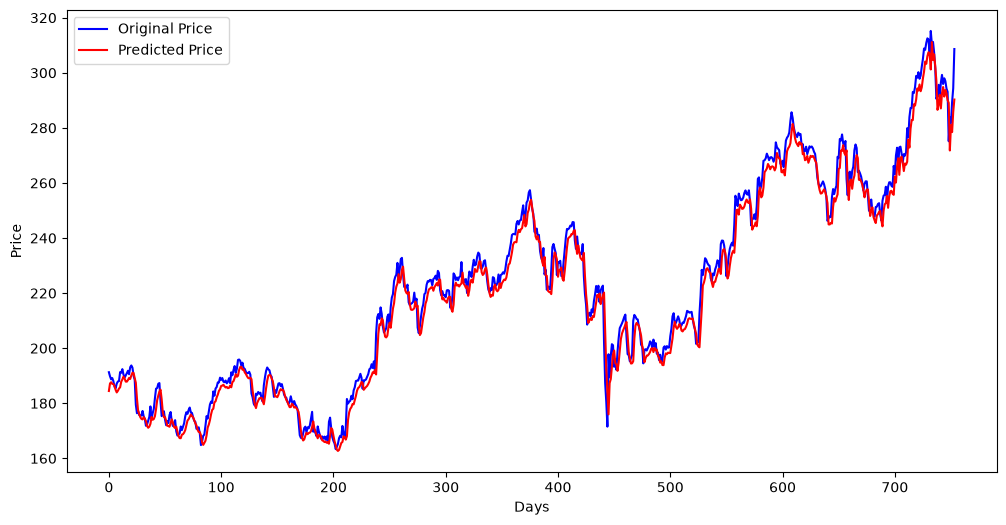

In [46]:
plt.figure(figsize=(12, 6))
plt.plot(y_test, 'b', label='Original Price')
plt.plot(y_predicted, 'r', label='Predicted Price')
plt.xlabel('Days')
plt.ylabel('Price')
plt.legend()

(140.0, 220.0)

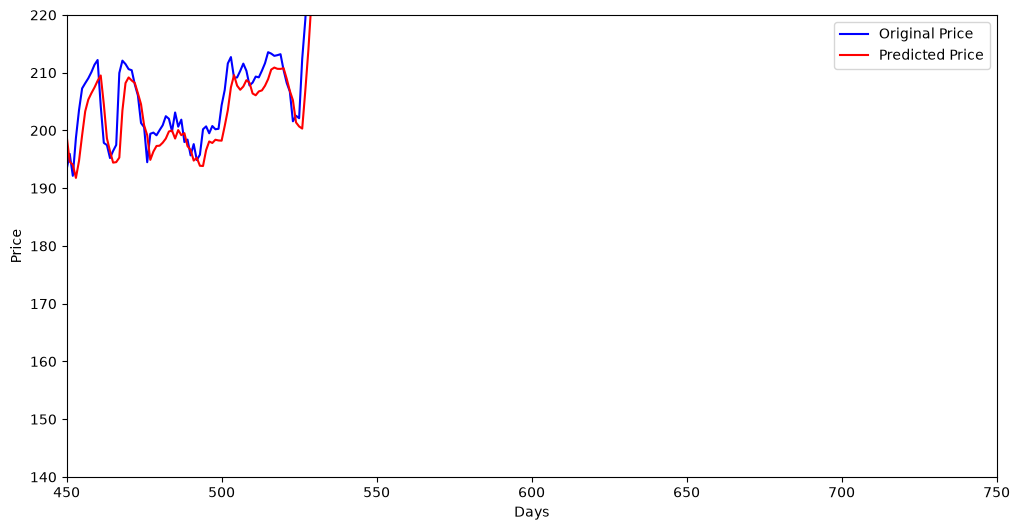

In [45]:
plt.figure(figsize=(12, 6))
plt.plot(y_test, 'b', label='Original Price')
plt.plot(y_predicted, 'r', label='Predicted Price')
plt.xlabel('Days')
plt.ylabel('Price')
plt.legend()
plt.xlim(450, 750) 
plt.ylim(140, 220) 

In [50]:
from sklearn.metrics import mean_squared_error, r2_score

In [48]:
mse = mean_squared_error(y_test, y_predicted)
print(f"Mean Squared Error : {mse}")

Mean Squared Error : 22.44143908785006


In [49]:
rmse = np.sqrt(mse)
print(f"Root Mean Squared Error: {rmse}")

Root Mean Squared Error: 4.737239606337225


In [51]:
r2 = r2_score(y_test, y_predicted)
print(f"R-Squared: {r2}")

R-Squared: 0.9834486010431653
